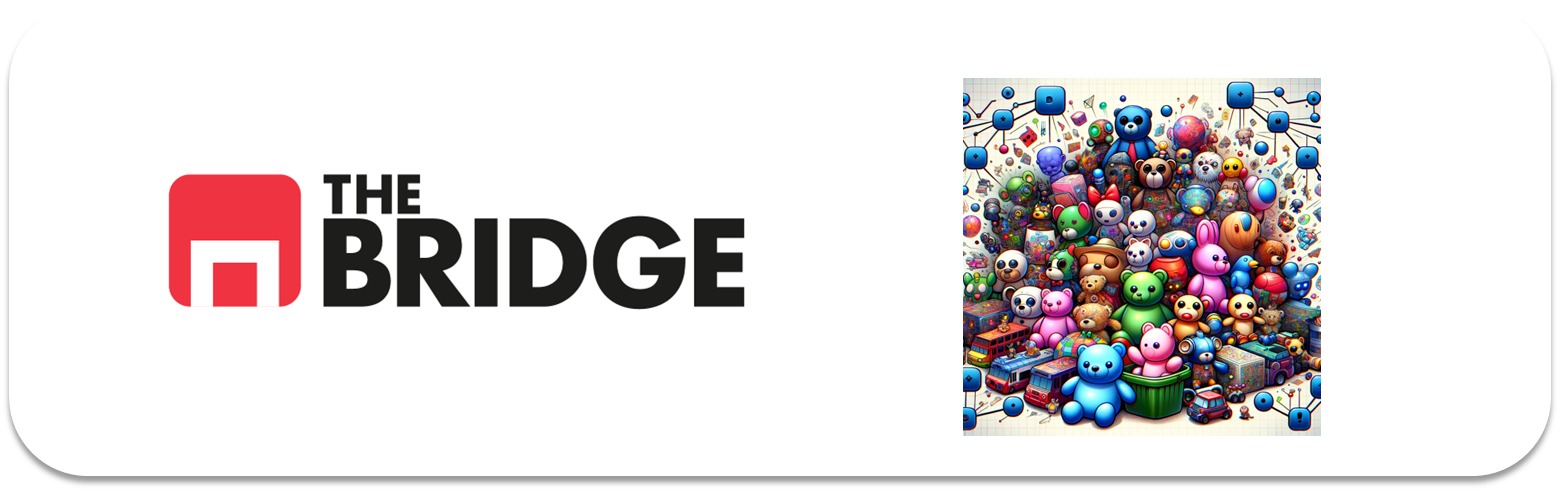

## PRACTICA OBLIGATORIA: **DBSCAN y Clustering Jerárquico**

* La práctica obligatoria de esta unidad consiste en un ejercicio de modelado no supervisado aplicado a clustering jerárquico y no jerárquico. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [94]:
# Common imports
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import bootcampviztools as bct
import itertools
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# to make this notebook's output stable across runs
np.random.seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# Ignore useless warnings (see SciPy issue #5998)
import warnings
warnings.filterwarnings(action="ignore", message="^internal gelsd")

### Parte I. Modelado

#### Descripción del problema.

En una planta de experimentación con nuevas bebidas energéticas están trabajando con diferentes mezclas de componentes para obtener posibles variedades de su producto estrella "NonstopU". El problema es que la fabricación de cada "prototipo" conlleva demasiado tiempo y las pruebas de sabores y de propiedades "non-stop" antisueño y antifatiga son costosas.  

En ese sentido quieren construir algún sistema de segmentación previa de mezclas sin probarlas solo indicando las cantidades de cada componente de la bebida. Tienen datos pero desgraciadamente de mezclas anteriores con diferentes medidas pero que por temas presupuestarios y de prioridad no se hicieron test con usuarios y potenciales clientes, es decir no tienen un target de capacidad antifatiga o de preferncia del usuario que puedas servirles para construir un clasificador clásico como han hecho otras veces.  

Han acudido a vosotros con la necesida de encontrar ese segmentador de posibles bebidas y con los datos de las mezclas no probadas anteriores por ver si vostros podéis ayudarles a encontrar algún tipo de segmentación que luego ello se encargarían de interpretar. No es requisito obligatorio pero les gustaría también poder establecer algún tipo de relación entre las segmentaciones (tipo cuales segmentos se "parecerían" más entre sí)

NOTA ORIENTATIVA: Los químicos no esperan que haya menos de 3 segmentos ni más de 5.  
NOTA OPERATIVA: El dataset con los datos que nos han dado los químicos está en "./data/empowering_drinks.csv"

**Se pide**: Construir al menos dos algoritmos de clustering (DBSCAN debe ser uno de ellos y el otro debería estar claro cual deberíamos usar dado el enunciado). Compararlos brevemente aunque sea meramente especulativo (¿Por qué es espculativo?)

**Se recomienda**: Visualizar las features dos a dos para escoger las mejores, no necesariamente hay que usar todas, ni tampoco quedarse en dos. Probar diferentes hiperparámetros en función de la nota orientativa y explicar porqué se han escogido los que finalmente se hayan escogido. 

Recuerda que el proceso es similar a lo que vimos en el otro tipo de aprendizaje:
1. Entender el problema
2. Cargar datos, visualizar.
3. MiniEDA: Selección de features
4. Tratamiento de Features.
5. Selección de modelos, selección de hiperparámetros
6. Entrenamiento, visualización de resultados.
7. Discusión de los mismos


In [95]:
path_to_file = './data/empowering_drinks.csv'
df = pd.read_csv(path_to_file, sep='|')

In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Azúcares               153 non-null    float64
 1   Vitamínas del grupo B  153 non-null    float64
 2   Cafeína                153 non-null    float64
 3   Ácido Cítrico          153 non-null    float64
 4   Taurina                153 non-null    float64
dtypes: float64(5)
memory usage: 6.1 KB


In [97]:
df.head()

,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
0,1.518613,0.232053,1.034819,1.013009,0.251717
1,0.246290,-0.827996,0.733629,0.965242,-0.293321
2,0.196879,1.109334,1.215533,1.395148,0.269020
3,1.691550,0.487926,1.466525,2.334574,1.186068
4,0.295700,1.840403,0.663351,-0.037874,-0.319276


In [98]:
df.describe()


,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
count,153.000000,153.000000,153.000000,153.000000,153.000000
mean,0.019231,0.037273,0.041057,0.080022,-0.044088
std,1.026182,0.995984,1.040928,1.009450,0.934399
min,-2.434235,-3.679162,-1.695971,-1.493188,-1.634288
25%,-0.816038,-0.499016,-1.043392,-0.738463,-0.799428
50%,0.061000,-0.023821,0.211566,-0.165254,-0.154899
75%,0.876275,0.707247,0.894264,0.917474,0.493956
max,2.259772,3.156325,3.062832,2.971473,2.431870


In [99]:
# Veo que los datos ya están escalados pq la media es cercana a 0 y 
# la desviación estándar es cercana a 1, y no hay valores nulos
mask = (df.select_dtypes(include='number') == 0).any(axis=1)
df_zeros = df[mask]
print(df_zeros)

Empty DataFrame
Columns: [Azúcares, Vitamínas del grupo B, Cafeína, Ácido Cítrico, Taurina]
Index: []


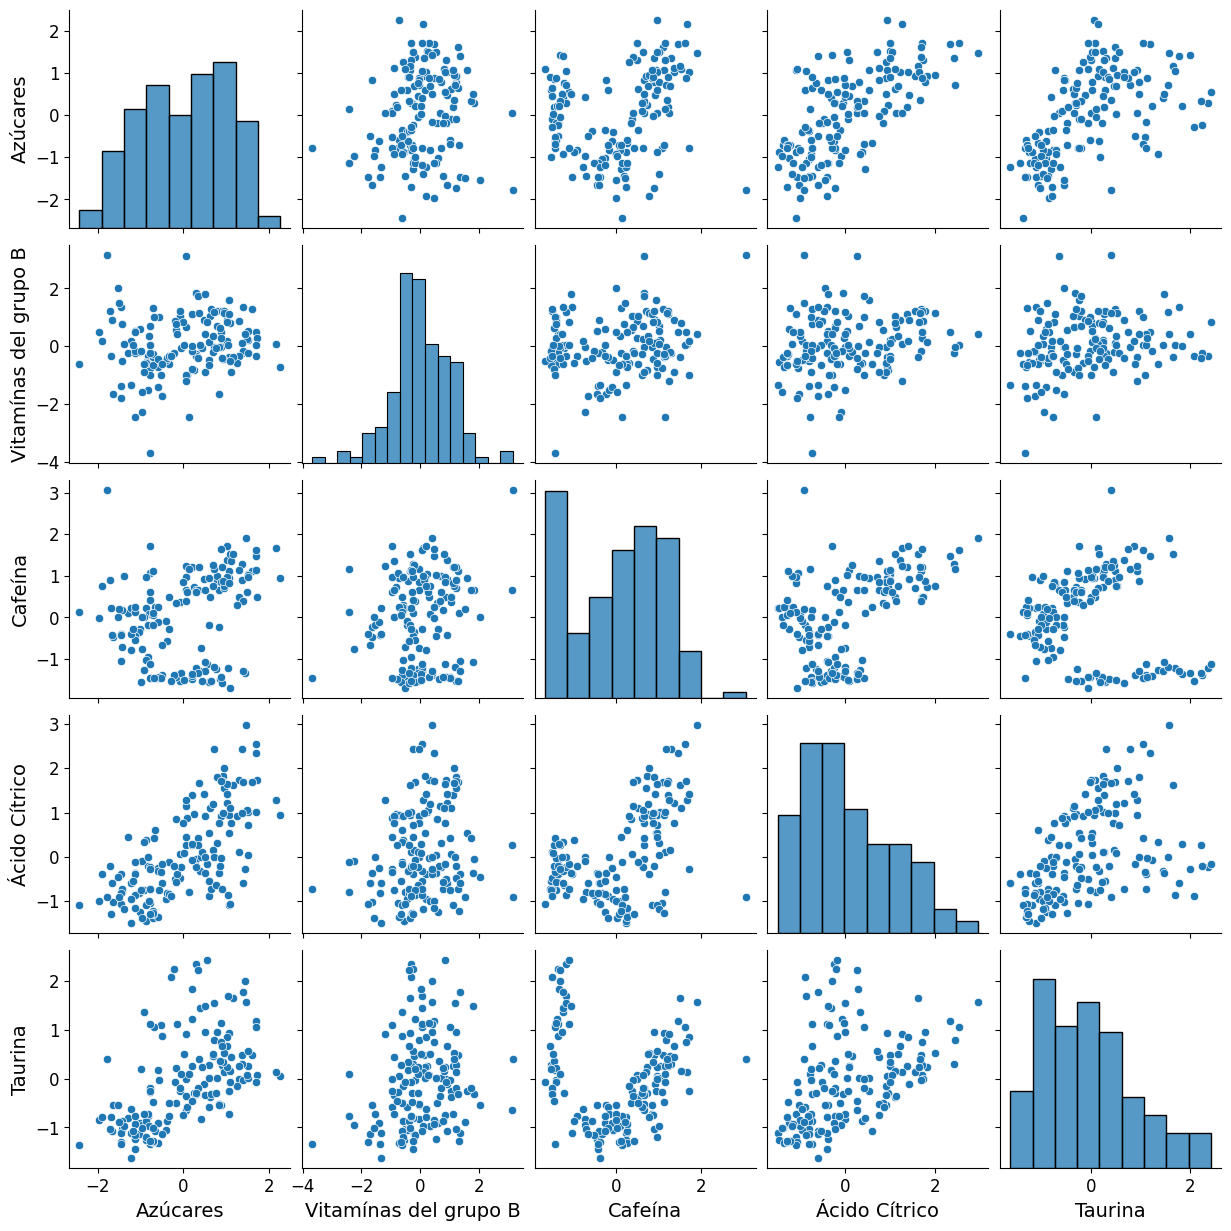

In [100]:
# Distribuciones de las features
sns.pairplot(df)


<Axes: >

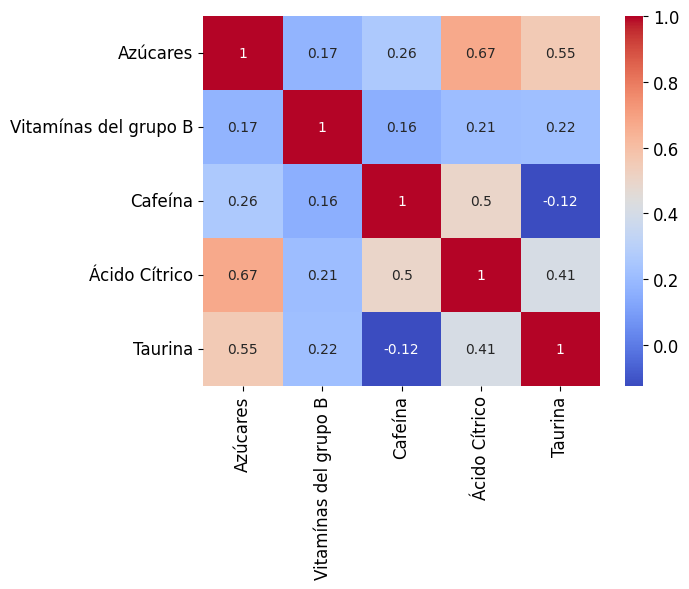

In [101]:
# Correlaciones
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")


In [102]:
# En este caso Azúcares y Ácido Cítrico tienen correlación alta entre sí, 
# así como Azúcares y Taurina y también Ácido Cítrico y Taurina
# Con lo que pienso que una buena opción es eliminar Azúcares y Ácido Cítrico, 
# quedándome con Taurina que tiene correlación alta con ambas 
df_copy = df.copy()

df_copy.drop(columns=['Azúcares', 'Ácido Cítrico'], inplace=True)
df_copy.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 3 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Vitamínas del grupo B  153 non-null    float64
 1   Cafeína                153 non-null    float64
 2   Taurina                153 non-null    float64
dtypes: float64(3)
memory usage: 3.7 KB


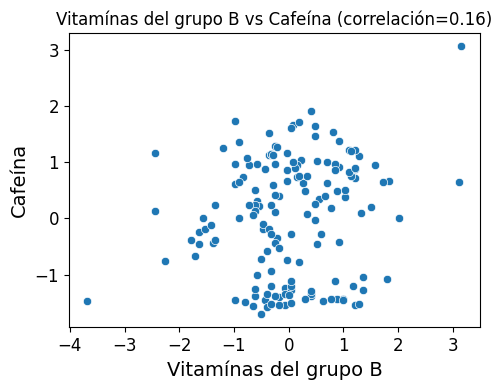

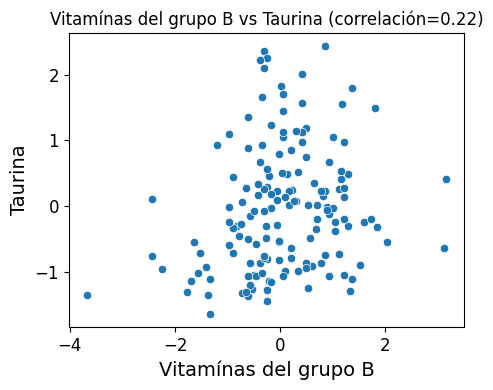

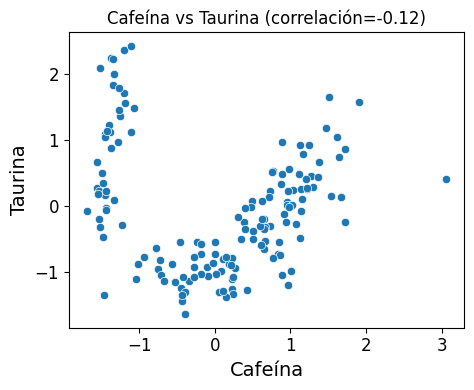

In [103]:
# dispersiones de 2 en 2 para ver su mapa de dispersión
num_cols = df_copy.select_dtypes(include='number').columns

for col1, col2 in itertools.combinations(num_cols, 2):
    plt.figure(figsize=(5, 4))
    sns.scatterplot(x=df_copy[col1], y=df_copy[col2])
    corr = df_copy[[col1, col2]].corr().iloc[0, 1]
    plt.title(f'{col1} vs {col2} (correlación={corr:.2f})')
    plt.xlabel(col1)
    plt.ylabel(col2)
    plt.tight_layout()
    plt.show()


In [104]:
# En el mapa de dispersión entre Vitaminas del grupo B y Taurina o Cafeína no parece
# definirse más de un sólo cluster, en cambio, en el mapa de dispersión entre Taurina y Cafeína
# almenos veo 3 grupos claros. Nos quedamos con estas 2 features ya que son las
# que tienen más probabilidades de darnos una clasificación fiable
df_copy.drop(columns=['Vitamínas del grupo B'], inplace=True)
df_copy.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Cafeína  153 non-null    float64
 1   Taurina  153 non-null    float64
dtypes: float64(2)
memory usage: 2.5 KB


In [105]:
def codo(df):
    # buscamos el mejor eps y mejor min_samples
    min_samples_list = [3, 4, 5, 6, 7, 8, 9, 10]
    plt.figure(figsize=(8, 5))

    for min_samples in min_samples_list:
        nn = NearestNeighbors(n_neighbors=min_samples)
        nn.fit(df)
        distances, _ = nn.kneighbors(df)
        sorted_distances = np.sort(distances[:, min_samples-1])
        plt.plot(sorted_distances, label=f"min_samples={min_samples}")

    plt.title("k-distance plot para distintos min_samples")
    plt.xlabel("Puntos ordenados")
    plt.ylabel("Distancia al k-ésimo vecino")
    plt.legend()
    plt.show()

In [106]:
def evaluar_dbscan(df, eps_values, min_samples_list):
    # vamos a ejecutar DBSCAN con distintos valores de eps y min_samples
    # para ver cuál es el mejor minimizando el número de anomalías 
    # Trabajaremos con eps entre 0.3 y 0.6 que es donde vemos el codo en el gráfico anterior
    # y con min_samples entre 3 y 10 para ver cómo afecta a la cantidad de clusters y ruido
    resultados = []
    for eps in eps_values:
        for min_samples in min_samples_list:
            dbscan = DBSCAN(eps=eps, min_samples=min_samples)
            labels = dbscan.fit_predict(df)

            n_clusters = len(set(labels))
            if -1 in labels:
                n_clusters = n_clusters - 1

            if n_clusters <= 5 and n_clusters > 2:  
                n_noise = np.sum(labels == -1)
                resultados.append((eps, min_samples, n_clusters, n_noise))

    # Ordena por mínimo ruido y máximo número de clusters
    resultados.sort(key=lambda x: (x[3], -x[2]))
 
    mejor_eps, mejor_min_samples, max_clusters, min_ruido = resultados[0]
    print(f'Mejor modelo: eps={mejor_eps:.2f}, min_samples={mejor_min_samples}, clusters={max_clusters}, ruido={min_ruido}')

    # Aplica el mejor modelo
    dbscan = DBSCAN(eps=mejor_eps, min_samples=mejor_min_samples)
    labels = dbscan.fit_predict(df)
    df['dbscan_label'] = labels
    df['dbscan_label'].value_counts()

    return dbscan

In [107]:
def plot_clustering(df, col1, col2, hue):
    plt.figure(figsize=(5, 4))
    sns.scatterplot(df, x=col1, y=col2, hue=hue, palette='Set1')
    plt.title(f'{col1} vs {col2}')
    plt.xlabel(col1)
    plt.ylabel(col2)
    plt.tight_layout()
    plt.show()

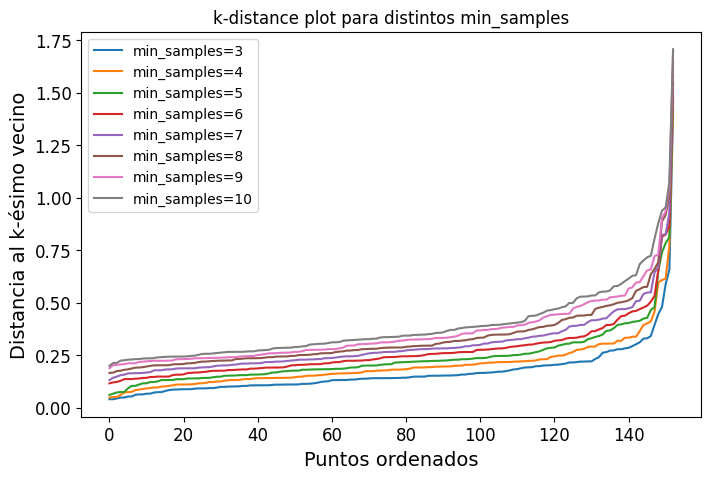

In [108]:
codo(df_copy)

In [109]:
# De la gráfica del codo para sól Taurina y Cafeína, 
# parece que un buen valor de eps podría estar entre 0.25 y 0.6, 
# para min_samples entre 3 y 10
eps_values = np.arange(0.25, 0.6, 0.01)
min_samples_list = [3, 4, 5, 6, 7, 8, 9, 10]
dbscan_copy = evaluar_dbscan(df_copy, eps_values, min_samples_list)


Mejor modelo: eps=0.29, min_samples=3, clusters=3, ruido=5


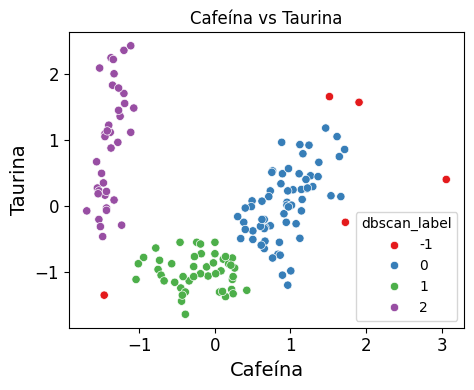

In [110]:
plot_clustering(df_copy, 'Cafeína', 'Taurina', 'dbscan_label')

In [111]:
# Vemos como DBSCAN ha identificado 3 clusters con 5 anomalías
# cuando tratmos un dataset con sólo Cafeína y Taurina

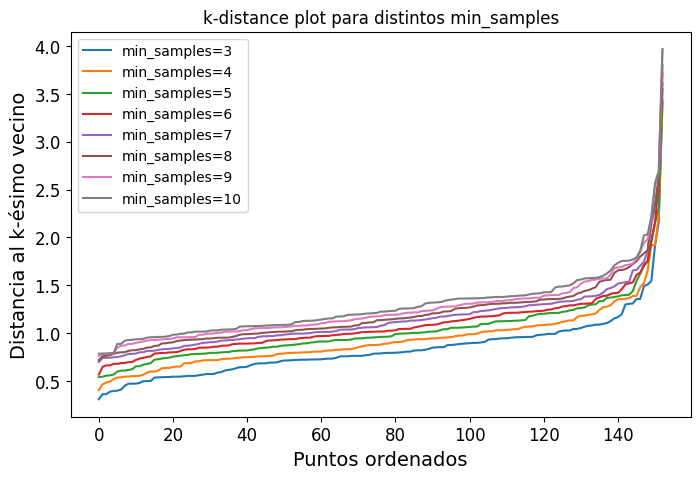

In [112]:
codo(df)

In [113]:
# De la gráfica del codo para TODO el dataset, 
# parece que un buen valor de eps podría estar entre 1 y 1.8, 
# para min_samples entre 3 y 10
eps_values = np.arange(1, 1.8, 0.01)
min_samples_list = [3, 4, 5, 6, 7, 8, 9, 10]
dbscan = evaluar_dbscan(df, eps_values, min_samples_list)

Mejor modelo: eps=1.05, min_samples=3, clusters=3, ruido=8


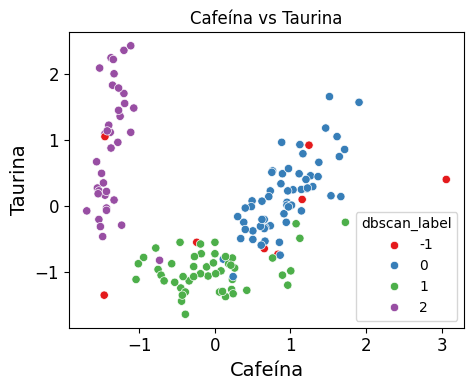

In [114]:
plot_clustering(df, 'Cafeína', 'Taurina', 'dbscan_label')

In [115]:

# Vemos como DBSCAN ha identificado 3 clusters con 8 anomalías
# cuando tratamos el dataset entero
# Nos quedamos con el Dataset con el que conseguimos menos ruido
# que es df_copy

In [116]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Cafeína       153 non-null    float64
 1   Taurina       153 non-null    float64
 2   dbscan_label  153 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 3.7 KB


In [117]:
def linkage_ward(df):
    Z = linkage(df, method='ward')
    plt.figure(figsize=(10, 5))
    dendrogram(Z, labels=df.index, leaf_rotation=90)
    plt.title('Dendrograma (linkage ward)')
    plt.xlabel('Índice de muestra')
    plt.ylabel('Distancia')
    plt.tight_layout()
    plt.show()

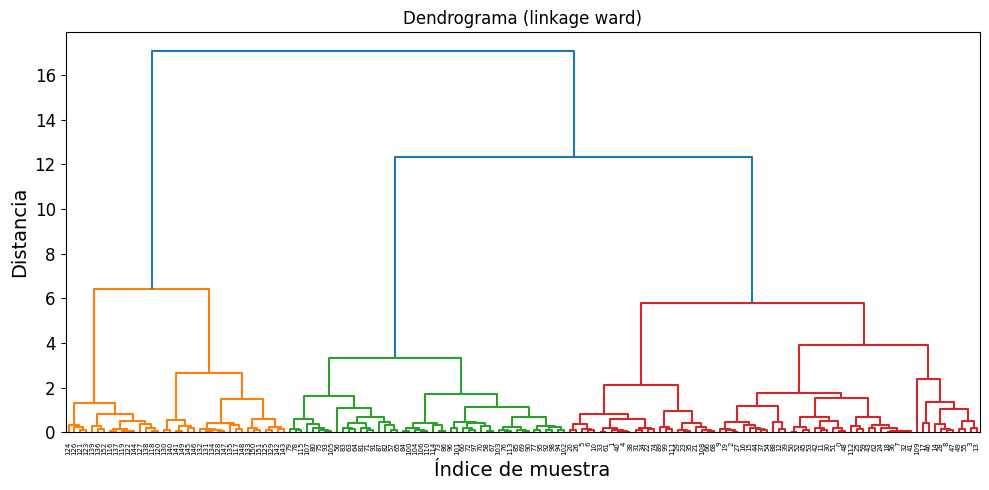

In [118]:
# Clustering jerárquico: df_copy sin las labels de dbscan
df_copy2 = df_copy.drop('dbscan_label', axis = 1)

# Deducimos cuales serían nuestros clusters con linkage
linkage_ward(df_copy2)

In [119]:
def AggClustering_ward(df, n_clusters):
    model = AgglomerativeClustering(n_clusters, linkage='ward')
    labels = model.fit_predict(df)
    df['cluster'] = labels
    print(df['cluster'].value_counts())

    return model, labels

In [120]:
# Vemos que se definen 3 clusters claramente
# Aplicamos un modelo jerárquico con 3 clusters
model_jer, labels_jer = AggClustering_ward(df_copy2, 3)

cluster
1    69
2    47
0    37
Name: count, dtype: int64


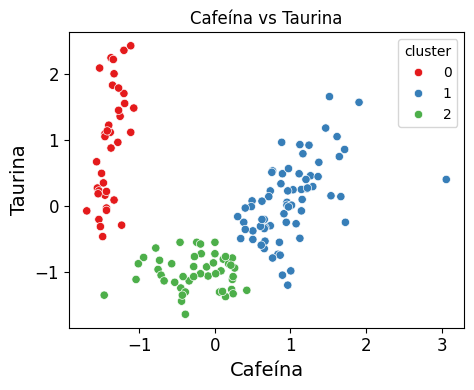

In [121]:
plot_clustering(df_copy2, 'Cafeína', 'Taurina', 'cluster')

In [122]:
# La verdad que mucho mejor ya que no tenemos ruido


### Parte II. Nuevos experimentos

Los químicos están muy esperanzados con los modelos que les habéis mostrado y os pasan una lista de nuevos experimentos para que los clasifiquéis. Emplea uno de los modelos construidos, el que te resulte más sencillo, para segmentar los nuevos experimentos que puedes encontrar en "./data/new_experiments.csv"

In [123]:
path_to_file = './data/new_experiments.csv'
df_new = pd.read_csv(path_to_file, sep='|')
df_new.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Azúcares               6 non-null      float64
 1   Vitamínas del grupo B  6 non-null      float64
 2   Cafeína                6 non-null      float64
 3   Ácido Cítrico          6 non-null      float64
 4   Taurina                6 non-null      float64
dtypes: float64(5)
memory usage: 372.0 bytes


In [124]:
df_new.describe()

,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
count,6.000000,6.000000,6.000000,6.000000,6.000000
mean,0.028059,0.085839,-0.348982,0.106490,-0.032337
std,1.205271,0.826463,1.139233,1.157346,1.143657
min,-1.680724,-1.412851,-1.565455,-1.193845,-0.976782
25%,-0.766628,-0.106066,-1.211557,-0.368265,-0.704263
50%,0.165997,0.323436,-0.561488,-0.149331,-0.593957
75%,0.876275,0.561033,0.352122,0.212905,0.418256
max,1.481555,0.890014,1.366128,2.239039,1.956043


In [125]:
# Vemos que los datos nuevos tb están estandarizados y no hay nulos
print(df_new[mask])


Empty DataFrame
Columns: [Azúcares, Vitamínas del grupo B, Cafeína, Ácido Cítrico, Taurina]
Index: []


C:\Users\jvend\AppData\Local\Temp\ipykernel_39260\2328270093.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print(df_new[mask])


In [126]:
# Como nuestro modelo model_jer no tiene predict
# vamos a juntar nuestro dataset original con el nuevo
# Nos quedaremos con Cafeína y Taurina y volveremos a entrenar
X_combined = pd.concat([df[['Cafeína', 'Taurina']], df_new[['Cafeína', 'Taurina']]])
labels_tot = model_jer.fit_predict(X_combined)

df_new['cluster'] = labels_tot[-len(df_new):]

# La predicción es
df_new


,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina,cluster
0,1.481555,0.305159,1.366128,2.239039,0.731870,1
1,0.616869,0.890014,0.583034,0.312420,-0.665332,1
2,-1.680724,0.341713,-0.340615,-0.213021,-0.976782,2
3,-0.284874,-1.412851,-0.782361,-1.193845,-0.717240,2
4,-0.927212,0.634140,-1.565455,-0.085641,-0.522583,0
5,0.962743,-0.243142,-1.354622,-0.420013,1.956043,0


### Parte III. EXTRA (Voluntario): 6 meses después...

La unidad de experimentación recibió un presupuesto adicional gracias a los modelos que les proporcionastes e hizo pruebas con cliente y obtuvo resultados como para clasificar cada bebida en terminos de "energización" en tres niveles (1, media; 2, media-alta, 3, alta). El resultado de los mismos está en el fichero adecuado en el directorio data y alineado con los experimentos iniciales y al final con los nuevos experimentos de la parte anterior.

Evalua la segmentación de los modelos creados en la primera parte.

In [127]:
# leo los resultados 
path_to_file = './data/power_results.csv'
df_res = pd.read_csv(path_to_file, sep='|')
df_res.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   class   159 non-null    int64
dtypes: int64(1)
memory usage: 1.4 KB


In [128]:
df_res["class"].value_counts()

class
2    62
1    58
3    39
Name: count, dtype: int64

In [129]:
unique, counts = np.unique(labels_tot, return_counts=True)
for label, count in zip(unique, counts):
    print(f"Cluster {label}: {count} registros")

Cluster 0: 39 registros
Cluster 1: 71 registros
Cluster 2: 49 registros


In [130]:
indices_cluster_0 = df_copy2.index[df_copy2['cluster'] == 0].tolist()
indices_cluster_1 = df_copy2.index[df_copy2['cluster'] == 1].tolist()
indices_cluster_2 = df_copy2.index[df_copy2['cluster'] == 2].tolist()

In [131]:
indices_classe_1 = df_res.index[df_res['class'] == 1].tolist()
indices_classe_2 = df_res.index[df_res['class'] == 2].tolist()
indices_classe_3 = df_res.index[df_res['class'] == 3].tolist()

In [132]:
# Compara la intersección entre clusters y clases
for i, indices_cluster in enumerate([indices_cluster_0, indices_cluster_1, indices_cluster_2]):
    set_cluster = set(indices_cluster)
    for j, indices_classe in enumerate([indices_classe_1, indices_classe_2, indices_classe_3]):
        set_classe = set(indices_classe)
        interseccion = set_cluster & set_classe
        print(f"Cluster {i} y Clase {j+1}: {len(interseccion)} elementos en común")

Cluster 0 y Clase 1: 0 elementos en común
Cluster 0 y Clase 2: 0 elementos en común
Cluster 0 y Clase 3: 37 elementos en común
Cluster 1 y Clase 1: 56 elementos en común
Cluster 1 y Clase 2: 13 elementos en común
Cluster 1 y Clase 3: 0 elementos en común
Cluster 2 y Clase 1: 0 elementos en común
Cluster 2 y Clase 2: 47 elementos en común
Cluster 2 y Clase 3: 0 elementos en común


In [133]:
# Vemos que hay diferencia entre los clusters y las clases, 
# en total ha clasificado bien 37+56+47 = 140 de 159  registros, 
# es decir 140/159 = 88% de acierto,
# a mi entender está bastante bien,


